# CCB Depth Dose and Wedge Profile Analysis

Two plots:
1. **Depth dose curve**: IC measurement vs MC simulation for CCB
2. **Dose profile after wedge**: MC simulation for CCB

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("../../output/pub2026/mc/data")

## Plot 1: Depth Dose Curve — IC Measurement vs MC Simulation (CCB)

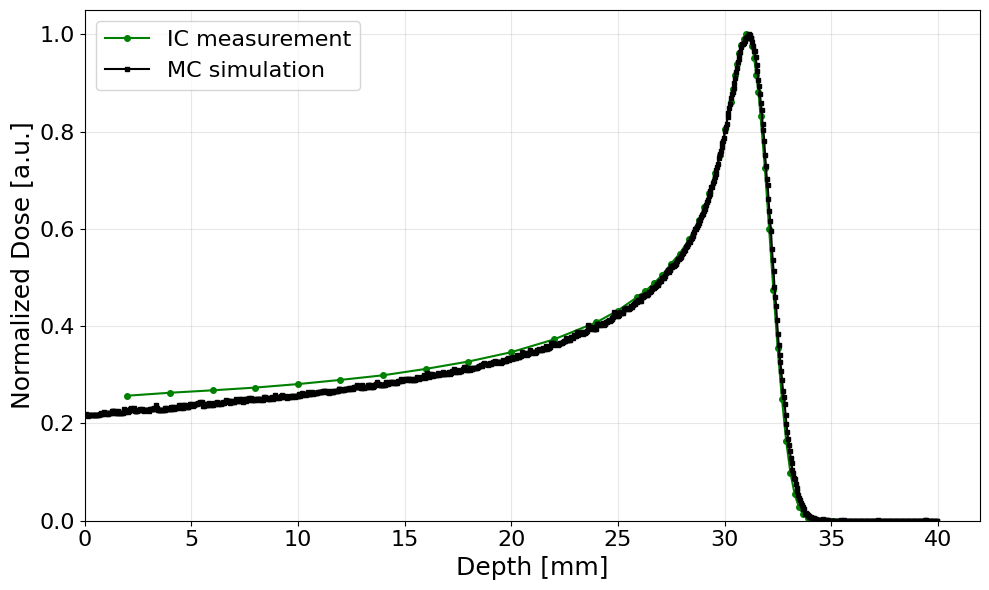

In [2]:
# Load depth dose data from HDF5 (generated by mc_depth_validation pipeline)
df_exp = pd.read_hdf(output_dir / "ccb.h5", key="exp_depth_dose")  # IC measurement
df_mc_depth = pd.read_hdf(output_dir / "ccb.h5", key="mc_depth_dose")  # MC simulation

TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
ax.set_facecolor('none')
ax.plot(df_exp["x"], df_exp["y"], "o-", color="green", markersize=4, linewidth=1.5, label="IC measurement")
ax.plot(df_mc_depth["depth"], df_mc_depth["dose"], "s-", color="black", markersize=3, linewidth=1.5, label="MC simulation")
ax.set_xlabel("Depth [mm]", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Normalized Dose [a.u.]", fontsize=LABEL_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)
ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 2: MC Dose Profile After Wedge (CCB)

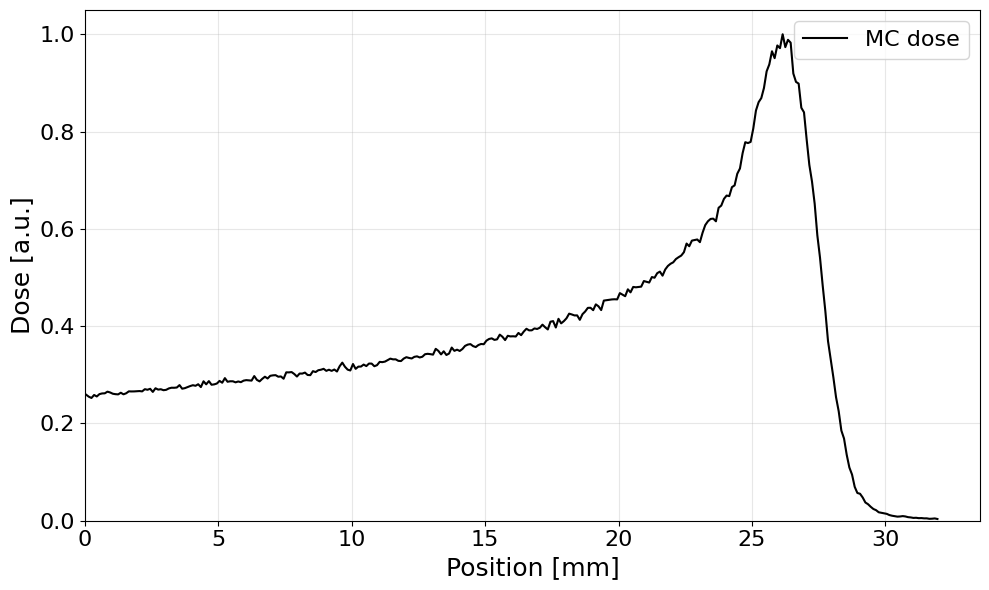

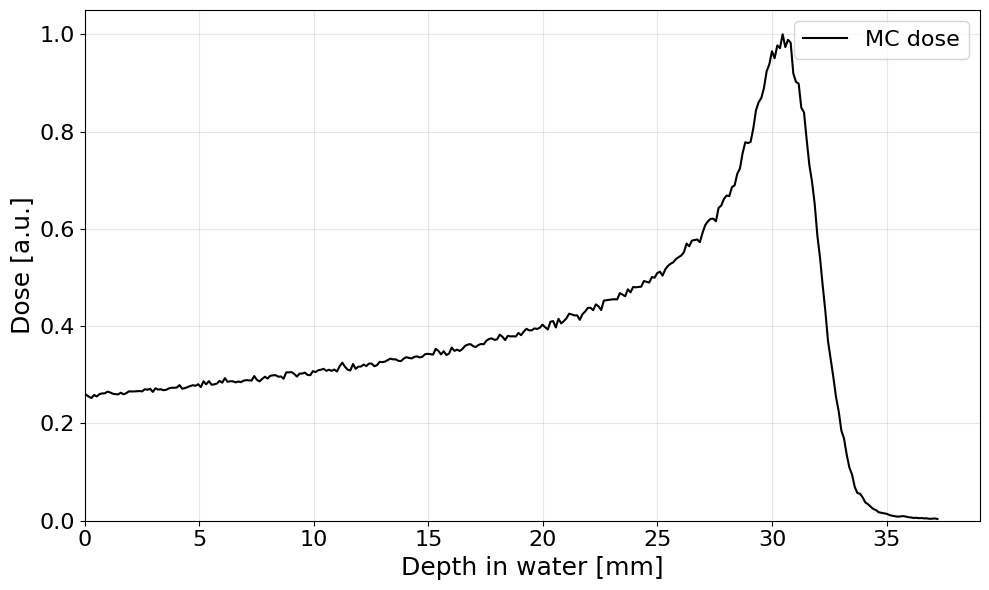

In [3]:
# Load MC wedge profile (generated by mc_wedge pipeline)
df_wedge = pd.read_csv(output_dir / "mc_ccb.csv")

TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16
WATER_EQ_FACTOR = 1.165

fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
ax.set_facecolor('none')
ax.plot(df_wedge["depth"], df_wedge["dose"], "-", color="black", linewidth=1.5, label="MC dose")
ax.set_xlabel("Position [mm]", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Dose [a.u.]", fontsize=LABEL_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)
ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
ax.set_facecolor('none')
ax.plot(df_wedge["depth"] * WATER_EQ_FACTOR, df_wedge["dose"], "-", color="black", linewidth=1.5, label="MC dose")
ax.set_xlabel("Depth in water [mm]", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Dose [a.u.]", fontsize=LABEL_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)
ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()